# Citi Bike Demand Forecasting — Exploratory Data Analysis

## Problem Statement

Bike-share stations can experience temporary bike shortages or surpluses when departures and arrivals become unbalanced.

The goal of this project is to:

- Forecast **hourly bike departures and arrivals** for high-activity Citi Bike stations.
- Use historical demand patterns to estimate future station-level demand.
- Calculate expected station **net flow**:

  **Net Flow = Predicted Arrivals − Predicted Departures**

- Use the predicted imbalance to identify stations that may require **bike rebalancing**.

A negative predicted net flow indicates **deficit pressure** because more bikes are expected to leave than arrive. A positive predicted net flow indicates **surplus pressure** because more bikes are expected to arrive than leave.

## Project Scope

The project uses official Citi Bike trip data from **April–June 2026**, containing approximately **13.94 million raw trip records**.

The forecasting analysis focuses on **20 high-activity stations**, selected using the training period only to avoid future-data leakage.

Forecasting is performed at the **station-hour level** rather than for individual trips.

## Purpose of This Notebook

This notebook focuses on exploratory data analysis before model training.

The analysis has two levels:

1. Inspect a **100,000-row sample** of the original Citi Bike trip data to understand the raw schema and basic data quality.
2. Analyze the processed **station-hour dataset** created in PostgreSQL to understand temporal and station-level demand patterns.

The full raw dataset is not loaded into notebook memory. The production ingestion pipeline processes the complete dataset in chunks.

In [9]:
# Set up project paths and imports so the notebook can access
# the same PostgreSQL data utilities used by the main pipeline.

from pathlib import Path
import sys
import zipfile

import matplotlib.pyplot as plt
import pandas as pd


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


from src.data import load_hourly_demand


print("Project root resolved:", PROJECT_ROOT.name)

Project root resolved: bike-share-demand-forecasting


## 1. Raw Citi Bike Trip Data

The complete project dataset contains **13,939,717 raw trip rows across 15 CSV files** covering April–June 2026.

Loading all raw trips into a notebook would add unnecessary memory and runtime cost. Instead, this section inspects **100,000 rows** from one source CSV.

The complete dataset is processed separately by the chunked ingestion pipeline in `scripts/load_trips.py`.

In [11]:
# Read a manageable raw-data sample to inspect the original
# Citi Bike schema without loading the full ~14M-trip dataset.

raw_zip_path = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "202604-citibike-tripdata.zip"
)

if not raw_zip_path.exists():
    raise FileNotFoundError(
        "Raw Citi Bike ZIP file not found in data/raw."
    )


with zipfile.ZipFile(raw_zip_path) as archive:
    csv_files = sorted(
        name
        for name in archive.namelist()
        if name.lower().endswith(".csv")
    )

    first_csv = csv_files[0]

    with archive.open(first_csv) as file:
        raw_sample = pd.read_csv(
            file,
            nrows=100_000,
            dtype={
                "ride_id": "string",
                "start_station_id": "string",
                "end_station_id": "string",
            },
        )


print("Source CSV:", first_csv)
print("Sample rows:", f"{len(raw_sample):,}")

raw_sample.head()

Source CSV: 202604-citibike-tripdata-part1.csv
Sample rows: 100,000


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,C88217D5C42993C6,classic_bike,2026-04-06 18:55:38.804,2026-04-06 19:04:03.989,E 88 St & Park Ave,7293.10,E 106 St & 1 Ave,7456.03,40.781411,-73.955959,40.789253,-73.939562,member
1,44E5BC08D0125145,classic_bike,2026-04-09 01:48:51.203,2026-04-09 01:58:40.980,Broadway & W 61 St,7014.12,West End Ave & W 60 St,7059.08,40.770030,-73.981968,40.772370,-73.990050,member
2,D4EA18EA685E8D59,electric_bike,2026-04-04 03:21:33.088,2026-04-04 03:33:35.930,Delancey St & Eldridge St,5414.07,Lexington Ave & E 24 St,6089.07,40.719383,-73.991479,40.740259,-73.984092,member
3,5BA741D2CAC6AD6A,electric_bike,2026-04-11 11:58:36.715,2026-04-11 14:07:16.782,Cherry St,5181.04,E 13 St & 2 Ave,5820.08,40.712199,-73.979481,40.731539,-73.985302,member
4,0804FB9898A542A3,classic_bike,2026-04-07 09:37:46.372,2026-04-07 09:45:39.175,Delancey St & Eldridge St,5414.07,E 13 St & 2 Ave,5820.08,40.719383,-73.991479,40.731539,-73.985302,casual


In [12]:
# Inspect the source columns and inferred data types to understand
# what fields are available before cleaning and aggregation.

print("Number of columns:", len(raw_sample.columns))

print("\nColumns:")
for column in raw_sample.columns:
    print("-", column)

print("\nData types:")
print(raw_sample.dtypes)

Number of columns: 13

Columns:
- ride_id
- rideable_type
- started_at
- ended_at
- start_station_name
- start_station_id
- end_station_name
- end_station_id
- start_lat
- start_lng
- end_lat
- end_lng
- member_casual

Data types:
ride_id                string
rideable_type             str
started_at                str
ended_at                  str
start_station_name        str
start_station_id       string
end_station_name          str
end_station_id         string
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual             str
dtype: object


In [13]:
# Measure missing values in the raw sample to identify source
# fields that may require validation during ingestion.

raw_missing = (
    raw_sample
    .isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_rows")
)

raw_missing["missing_pct"] = (
    raw_missing["missing_rows"]
    / len(raw_sample)
    * 100
).round(2)

raw_missing

,missing_rows,missing_pct
start_station_name,46,0.05
start_lat,46,0.05
start_lng,46,0.05
start_station_id,46,0.05
end_station_id,17,0.02
end_lng,17,0.02
end_lat,17,0.02
rideable_type,0,0.00
ride_id,0,0.00
ended_at,0,0.00


In [14]:
# Inspect the main categorical fields to understand the mix
# of bike types and customer membership categories.

print("Ride types:")
print(raw_sample["rideable_type"].value_counts())

print("\nMember / casual:")
print(raw_sample["member_casual"].value_counts())

Ride types:
rideable_type
electric_bike    72140
classic_bike     27860
Name: count, dtype: int64

Member / casual:
member_casual
member    83455
casual    16545
Name: count, dtype: int64


In [15]:
# Parse timestamps and calculate trip duration as a basic
# validity check on completed raw trip records.

raw_sample["started_at"] = pd.to_datetime(
    raw_sample["started_at"],
    errors="coerce",
)

raw_sample["ended_at"] = pd.to_datetime(
    raw_sample["ended_at"],
    errors="coerce",
)

raw_sample["trip_duration_minutes"] = (
    raw_sample["ended_at"]
    - raw_sample["started_at"]
).dt.total_seconds() / 60


raw_sample["trip_duration_minutes"].describe()

count    100000.000000
mean         12.539702
std          16.914239
min           1.001283
25%           5.197754
50%           8.814125
75%          15.279375
max        1437.620017
Name: trip_duration_minutes, dtype: float64

### Raw-Data Observation

The source table contains one row per bike trip. In the 100,000-row sample, missing station metadata is very low: about **0.05%** for start identifiers/coordinates and **0.02%** for end identifiers/coordinates.

Median trip duration is about **8.8 minutes**, with a long-tailed distribution. Duration is exploratory only and is not used as a forecasting feature.

Because the forecasting problem is not about predicting individual rides, raw trips are aggregated into **hourly departures and arrivals for each station**.

## 2. Processed Station-Hour Dataset

The complete raw trip data is loaded into PostgreSQL and aggregated into one row per station per hour.

For each station-hour:

- `departures` = bikes leaving the station
- `arrivals` = bikes returning to the station
- `net_flow` = arrivals − departures

The analysis contains a complete hourly timeline for **20 high-activity stations**.

The stations were selected using the training period only so future June activity did not influence station selection.

In [16]:
# Load the PostgreSQL station-hour table that serves as the
# analytical foundation for feature engineering and forecasting.

hourly = load_hourly_demand()

hourly["hour"] = pd.to_datetime(
    hourly["hour"]
)

print("Rows:", f"{len(hourly):,}")
print("Stations:", hourly["station_id"].nunique())

print(
    "Period:",
    hourly["hour"].min(),
    "to",
    hourly["hour"].max(),
)

hourly.head()

Rows: 43,680
Stations: 20
Period: 2026-04-01 00:00:00 to 2026-06-30 23:00:00


,station_id,hour,departures,arrivals,net_flow
0,5374.01,2026-04-01 00:00:00,4,9,5
1,5374.01,2026-04-01 01:00:00,2,6,4
2,5374.01,2026-04-01 02:00:00,3,2,-1
3,5374.01,2026-04-01 03:00:00,1,1,0
4,5374.01,2026-04-01 04:00:00,1,0,-1


In [17]:
# Verify that the processed dataset has one unique row per
# station-hour and retains genuine zero-demand observations.

duplicate_station_hours = hourly.duplicated(
    subset=["station_id", "hour"]
).sum()

print(
    "Duplicate station-hour rows:",
    duplicate_station_hours,
)

print("\nMissing values:")
print(hourly.isna().sum())


zero_activity = (
    (hourly["departures"] == 0)
    & (hourly["arrivals"] == 0)
).sum()

zero_activity_pct = (
    zero_activity
    / len(hourly)
    * 100
)

print(
    "\nZero-activity station-hours:",
    f"{zero_activity:,}",
)

print(
    "Zero-activity percentage:",
    f"{zero_activity_pct:.2f}%",
)

Duplicate station-hour rows: 0

Missing values:
station_id    0
hour          0
departures    0
arrivals      0
net_flow      0
dtype: int64

Zero-activity station-hours: 2,476
Zero-activity percentage: 5.67%


In [18]:
# Create simple calendar and activity fields used only for
# exploratory analysis of temporal and station-level patterns.

hourly["hour_of_day"] = hourly["hour"].dt.hour
hourly["day_of_week"] = hourly["hour"].dt.dayofweek

hourly["is_weekend"] = (
    hourly["day_of_week"] >= 5
)

hourly["day_type"] = hourly[
    "is_weekend"
].map(
    {
        False: "Weekday",
        True: "Weekend",
    }
)

hourly["total_activity"] = (
    hourly["departures"]
    + hourly["arrivals"]
)

## 3. Hour-of-Day Demand Pattern

Bike-share demand is expected to vary throughout the day.

Understanding recurring intraday behavior helps determine whether time-of-day and recent historical demand are useful forecasting signals.

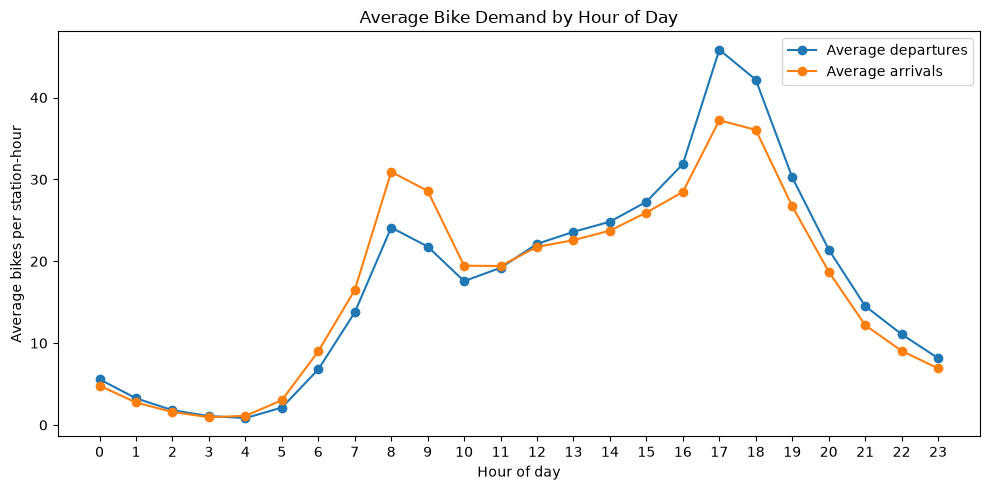

In [19]:
# Measure average departures and arrivals by hour to identify
# recurring intraday demand patterns.

hourly_pattern = (
    hourly
    .groupby("hour_of_day")[
        ["departures", "arrivals"]
    ]
    .mean()
)


fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.plot(
    hourly_pattern.index,
    hourly_pattern["departures"],
    marker="o",
    label="Average departures",
)

ax.plot(
    hourly_pattern.index,
    hourly_pattern["arrivals"],
    marker="o",
    label="Average arrivals",
)

ax.set_title(
    "Average Bike Demand by Hour of Day"
)

ax.set_xlabel("Hour of day")

ax.set_ylabel(
    "Average bikes per station-hour"
)

ax.set_xticks(range(24))
ax.legend()

fig.tight_layout()
plt.show()

### Interpretation

The hourly profile shows low overnight demand and stronger daytime and commuting-period activity. These recurring intraday patterns support the use of:

- hour-of-day information
- 1-hour historical lag
- 24-hour historical lag
- recent rolling-demand features

## 4. Weekday vs Weekend Demand

Bike-share behavior may differ between working days and weekends.

This comparison helps determine whether weekly calendar information contributes useful forecasting context.

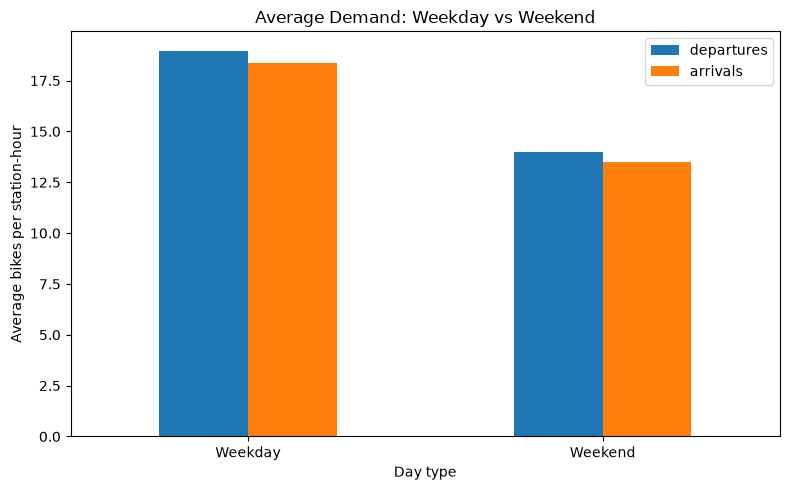

In [20]:
# Compare weekday and weekend activity to determine whether
# weekly calendar behavior should be represented in the model.

day_type_pattern = (
    hourly
    .groupby("day_type")[
        ["departures", "arrivals"]
    ]
    .mean()
)


ax = day_type_pattern.plot(
    kind="bar",
    figsize=(8, 5),
)

ax.set_title(
    "Average Demand: Weekday vs Weekend"
)

ax.set_xlabel("Day type")

ax.set_ylabel(
    "Average bikes per station-hour"
)

ax.tick_params(
    axis="x",
    rotation=0,
)

fig = ax.get_figure()
fig.tight_layout()

plt.show()

### Interpretation

Weekday station-hour activity is visibly higher than weekend activity for both departures and arrivals, showing that weekly calendar context can influence station demand.

The forecasting feature set therefore includes day-of-week information while preserving chronological ordering.

## 5. Station Activity

Demand is also location-dependent.

Although all 20 stations were selected as high-activity stations, activity levels can still vary considerably between individual locations.

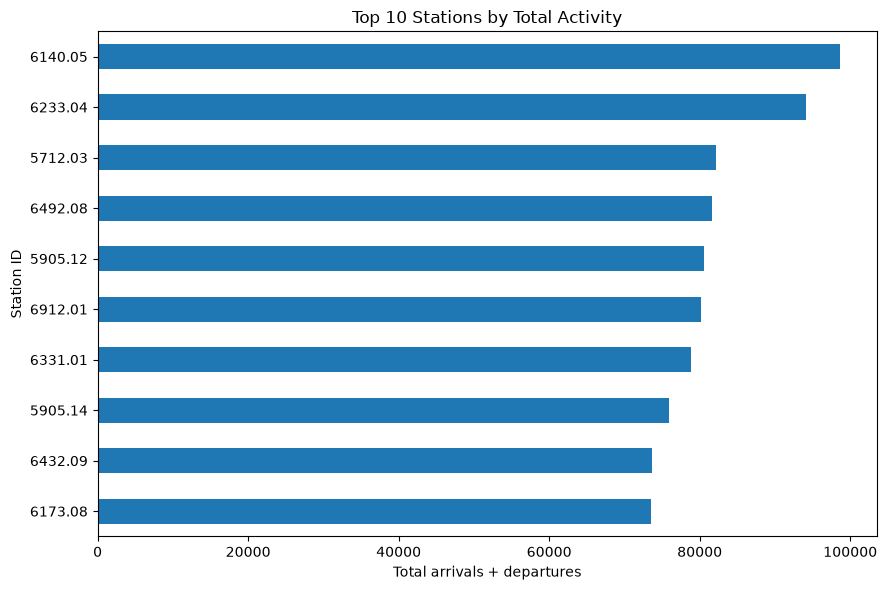

In [21]:
# Rank stations by total arrivals and departures to understand
# how overall demand varies across locations.

station_activity = (
    hourly
    .groupby("station_id")[
        "total_activity"
    ]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)


ax = station_activity.sort_values().plot(
    kind="barh",
    figsize=(9, 6),
)

ax.set_title(
    "Top 10 Stations by Total Activity"
)

ax.set_xlabel(
    "Total arrivals + departures"
)

ax.set_ylabel("Station ID")

fig = ax.get_figure()
fig.tight_layout()

plt.show()

## 6. Representative Station Demand Pattern

To inspect station-level temporal behavior, one representative station is selected objectively.

The station with the highest activity during the **training period only** is used. This avoids selecting a station afterward simply because its future behavior produces a convenient visualization.

In [22]:
# Select the busiest station using training-period information
# only so future June activity does not influence the example.

training_activity = hourly[
    hourly["hour"]
    < pd.Timestamp("2026-06-01")
].copy()


training_station_activity = (
    training_activity
    .groupby("station_id")[
        "total_activity"
    ]
    .sum()
    .sort_values(
        ascending=False
    )
)


representative_station = (
    training_station_activity.index[0]
)


print(
    "Representative station:",
    representative_station,
)

Representative station: 6140.05


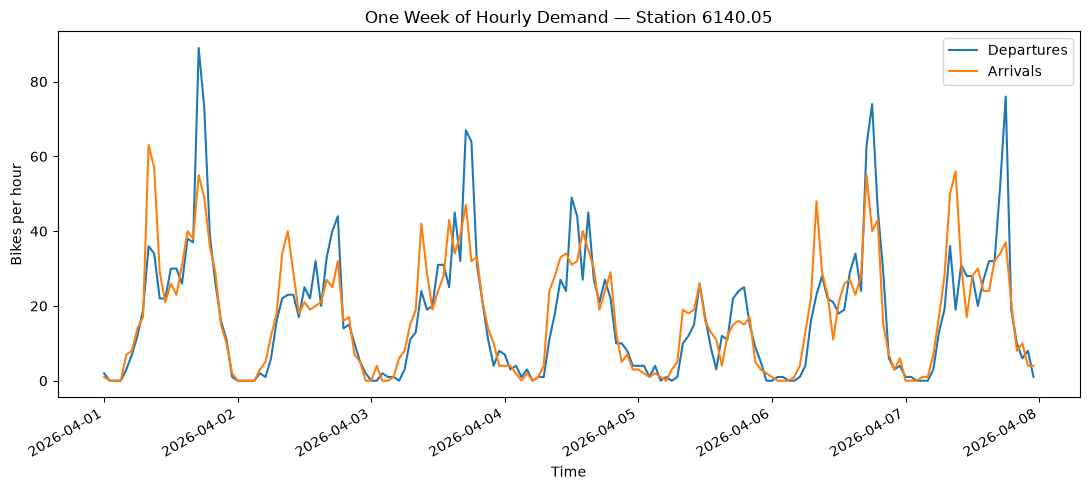

In [23]:
# Visualize one week of departures and arrivals to inspect
# recurring hourly and daily patterns at the selected station.

station_example = (
    hourly[
        hourly["station_id"]
        == representative_station
    ]
    .sort_values("hour")
    .head(24 * 7)
)


fig, ax = plt.subplots(
    figsize=(11, 5)
)

ax.plot(
    station_example["hour"],
    station_example["departures"],
    label="Departures",
)

ax.plot(
    station_example["hour"],
    station_example["arrivals"],
    label="Arrivals",
)

ax.set_title(
    f"One Week of Hourly Demand — "
    f"Station {representative_station}"
)

ax.set_xlabel("Time")
ax.set_ylabel("Bikes per hour")

ax.legend()

fig.autofmt_xdate()
fig.tight_layout()

plt.show()

### Interpretation

The station-level series illustrates how demand changes hour by hour while also showing recurring daily and weekly behavior.

This supports the use of historical features such as:

- `lag_1` — previous hour
- `lag_24` — same hour on the previous day
- `lag_168` — same hour one week earlier
- 24-hour rolling demand
- 168-hour rolling demand

These features are created using past observations only to prevent target leakage.

## 7. Dataset Summary

The following table summarizes the scale of the raw and processed datasets used by the project.

In [24]:
# Summarize the main dataset sizes and analysis period in one
# compact table for quick reference.

summary = pd.DataFrame(
    {
        "Metric": [
            "Raw rows inspected in notebook",
            "Full raw project trip rows",
            "Unique trips loaded into PostgreSQL",
            "Stations analyzed",
            "Station-hour rows",
            "Zero-activity station-hours",
            "Analysis start",
            "Analysis end",
        ],
        "Value": [
            f"{len(raw_sample):,}",
            "13,939,717",
            "13,939,205",
            hourly["station_id"].nunique(),
            f"{len(hourly):,}",
            f"{zero_activity:,}",
            hourly["hour"].min(),
            hourly["hour"].max(),
        ],
    }
)

summary

,Metric,Value
0,Raw rows inspected in notebook,"100,000"
1,Full raw project trip rows,"13,939,717"
2,Unique trips loaded into PostgreSQL,"13,939,205"
3,Stations analyzed,20
4,Station-hour rows,"43,680"
5,Zero-activity station-hours,"2,476"
6,Analysis start,2026-04-01 00:00:00
7,Analysis end,2026-06-30 23:00:00


## Key EDA Takeaways

- The source dataset contains approximately **13.94 million individual bike trips**, so the production pipeline uses chunked ingestion rather than loading the entire dataset into memory.
- A **100,000-row sample** is sufficient for inspecting the original schema and basic source-data quality in this notebook.
- The forecasting problem is modeled at the **station-hour level**, not at the individual-trip level.
- The processed dataset contains **43,680 station-hour observations across 20 stations**.
- Zero-activity hours are retained because they represent genuine station behavior rather than missing observations.
- Demand varies across both **time and station location**.
- Intraday and weekly patterns motivate the use of calendar, lag, and rolling-history features.
- Representative-station selection and forecasting evaluation preserve chronological ordering to reduce future-data leakage.

Model training, model comparison, final test evaluation, and the rebalancing decision layer are intentionally kept outside this notebook in the reproducible project pipeline.